## Ball and beam system modeling via NODEs with interpolated data inputs

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import gzip
import io
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import Akima1DInterpolator, CubicSpline
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
from torchdiffeq import odeint


We consider the ball and beam system: 

![](https://ctms.engin.umich.edu/CTMS/Content/BallBeam/Simulink/Modeling/figures/bb2.png)

Source: https://ctms.engin.umich.edu/CTMS/index.php?example=BallBeam&section=SimulinkModeling


In the following, we will build a model for the ball dynamics, that is, we want to predict ball position $y(t)=r(t)$ behavior given the input $u(t)=\\alpha(t)$. To do so, we are going to download real world data from [DaISy: Database for the Identification of Systems](https://homes.esat.kuleuven.be/~smc/daisy/daisydata.html), in particular the [ball and beam data set](https://ftp.esat.kuleuven.be/pub/SISTA/data/mechanical/ballbeam.txt).


In [11]:
def loaddata(normalize=True):
    url = "https://ftp.esat.kuleuven.be/pub/SISTA/data/mechanical/ballbeam.dat.gz"
    with urllib.request.urlopen(url) as response:
        with gzip.open(response, 'rt') as f:
            data = np.loadtxt(f)

    u = data[:, 0].astype(np.float32)  # input:  beam angle alpha(t)
    y = data[:, 1].astype(np.float32)  # output: ball position r(t)

    dt = np.float32(0.1)               # sampling time (from data description)

    if normalize:
        scaler_u = StandardScaler()
        scaler_y = StandardScaler()
        u = scaler_u.fit_transform(u.reshape(-1, 1)).ravel().astype(np.float32)
        y = scaler_y.fit_transform(y.reshape(-1, 1)).ravel().astype(np.float32)

    datasize = len(y)
    tspan = (np.float32(0.0), np.float32(1e2))
    tsteps = np.linspace(tspan[0], tspan[1], datasize, dtype=np.float32)

    return u, y, dt, tspan, tsteps


As a starting point, we will plot the downloaded ground truth data.

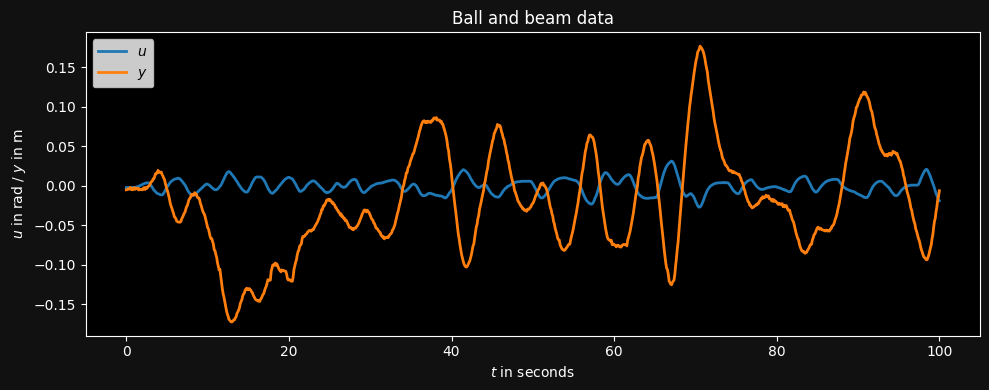

In [12]:
u, y, dt, tspan, tsteps = loaddata(normalize=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tsteps, u, label=r"$u$", linewidth=2)
ax.plot(tsteps, y, label=r"$y$", linewidth=2)
ax.set_title("Ball and beam data")
ax.set_xlabel(r"$t$ in seconds")
ax.set_ylabel(r"$u$ in rad / $y$ in m")
ax.legend(loc="upper left")
ax.set_facecolor("#000000")
fig.patch.set_facecolor("#111111")
ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white"); ax.title.set_color("white")
for spine in ax.spines.values(): spine.set_edgecolor("white")
plt.tight_layout()
plt.show()


As a first attempt, we will use a simple neural ordinary differential equation (NODE) which has only one internal state representing the ball position:
$$\frac{\mathrm{d}}{\mathrm{d}t}\hat{x}(t) = \hat{f}_w(\hat{x}(t), u(t)).$$


We use **`torchdiffeq`** for differentiable ODE solving (equivalent to Julia's `OrdinaryDiffEq` + `SciMLSensitivity`), **`torch.nn`** for the ANN (replacing `Lux.jl`), and **`scipy.interpolate`** for data interpolation (replacing `DataInterpolations.jl`).


As the input data $u(t_k)$ is sampled at discrete time steps $t_k=\{t_1, t_2,\ldots\}$, we use `Akima1DInterpolator` from SciPy to obtain a continuous interpolation $u(t)$.


In [13]:
u, y, dt, tspan, tsteps = loaddata(normalize=False)

# Akima interpolation — smooth, avoids oscillations near outliers
interp_input = Akima1DInterpolator(tsteps, u)


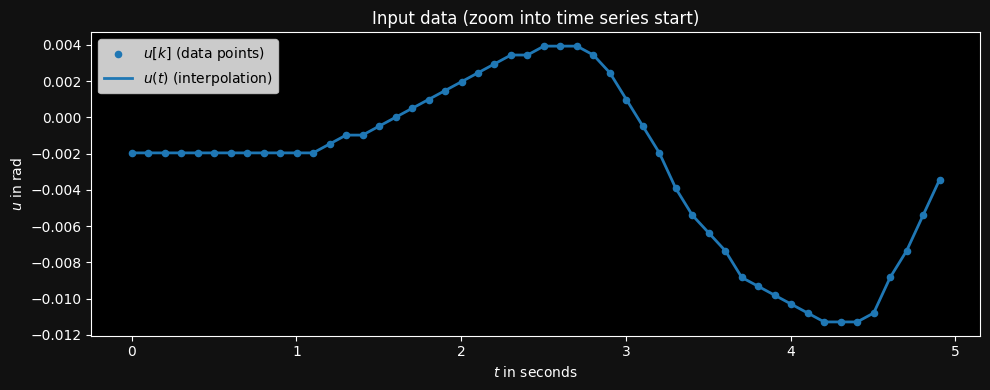

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(tsteps[:50], u[:50], label=r"$u[k]$ (data points)", s=20, zorder=5)
ax.plot(tsteps[:50], interp_input(tsteps[:50]), label=r"$u(t)$ (interpolation)", linewidth=2)
ax.set_title("Input data (zoom into time series start)")
ax.set_xlabel(r"$t$ in seconds")
ax.set_ylabel(r"$u$ in rad")
ax.legend(loc="upper left")
ax.set_facecolor("#000000")
fig.patch.set_facecolor("#111111")
ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white"); ax.title.set_color("white")
for spine in ax.spines.values(): spine.set_edgecolor("white")
plt.tight_layout()
plt.show()


We define a simple feedforward ANN as the RHS of the NODE:

In [15]:
torch.manual_seed(234)

# NODE Model 1: single state (x = r), inputs: [x, u(t)]
class NODEFunc1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 40),
            nn.Tanh(),
            nn.Linear(40, 1),
        )

    def forward(self, t, x):
        # x shape: (batch, 1)
        u_t = torch.tensor([[float(interp_input(t.item()))]], dtype=torch.float32)
        inp = torch.cat([x, u_t], dim=-1)
        return self.net(inp)

node_func1 = NODEFunc1()

# Convert data to tensors
y_tensor = torch.tensor(y, dtype=torch.float32)
tsteps_tensor = torch.tensor(tsteps, dtype=torch.float32)
u0_1 = torch.tensor([[y[0]]], dtype=torch.float32)  # initial condition


Define the ODE solver wrapper and the quadratic loss function:

In [16]:
def predict_NODE1(model):
    """Integrate the NODE and return predicted trajectory."""
    pred = odeint(model, u0_1, tsteps_tensor, method='rk4', options={'step_size': float(dt)})
    return pred[:, 0, 0]  # shape: (T,)

def loss_NODE1(model):
    pred = predict_NODE1(model)
    return torch.sum((y_tensor - pred) ** 2)


Train the NODE using LBFGS (closest Python equivalent to BFGS from Optim.jl):

In [17]:
optimizer1 = torch.optim.LBFGS(node_func1.parameters(), lr=0.01, max_iter=50, history_size=10,
                                line_search_fn='strong_wolfe')
losses1 = []

def closure1():
    optimizer1.zero_grad()
    loss = loss_NODE1(node_func1)
    loss.backward()
    losses1.append(loss.item())
    return loss

print("Training NODE Model 1 (single state)...")
optimizer1.step(closure1)
print(f"Final loss: {losses1[-1]:.4f}")


Training NODE Model 1 (single state)...
Final loss: 4.3140


Let's compare the model output with the ground truth:

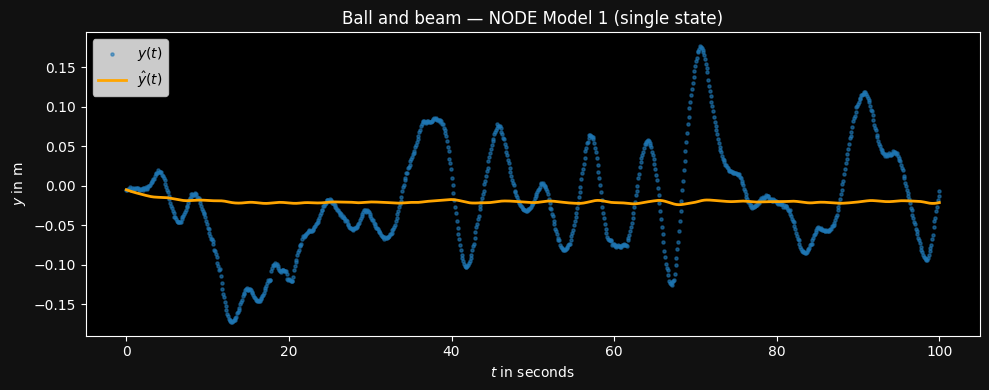

In [18]:
with torch.no_grad():
    pred1 = predict_NODE1(node_func1).numpy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(tsteps, y, label=r"$y(t)$", s=5, alpha=0.6)
ax.plot(tsteps, pred1, label=r"$\hat{y}(t)$", linewidth=2, color="orange")
ax.set_title("Ball and beam — NODE Model 1 (single state)")
ax.set_xlabel(r"$t$ in seconds")
ax.set_ylabel(r"$y$ in m")
ax.legend(loc="upper left")
ax.set_facecolor("#000000")
fig.patch.set_facecolor("#111111")
ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white"); ax.title.set_color("white")
for spine in ax.spines.values(): spine.set_edgecolor("white")
plt.tight_layout()
plt.show()



Obviously, the NODE topology was not suitable to model the ball and beam dynamics. Hence, we need to extend the model scope by incorporating more a priori knowledge.

Using Newton's mechanics (or a suitable lecture book) while assuming a rather small angle $\alpha(t)$, we can derive the following simple ODE:
$$\left(\frac{J}{R^2}+m\right)\ddot{r}(t) = -m g \alpha(t)$$
where $R$, $m$ and $J$ are the ball's radius, mass and inertia as well as $g$ being the gravitational acceleration. Hence, we have a second order ODE which we can rewrite into state-space form as
$$\frac{\mathrm{d}}{\mathrm{d} t}\begin{bmatrix}r(t)\\\\\dot{r}(t)\end{bmatrix} = \begin{bmatrix}\dot{r}(t) \\\\ -\frac{m g R^2}{J + mR^2} \alpha(t)\end{bmatrix}.$$

From this excursion into Newton's mechanics we can conclude that our previous single-state NODE was insufficient: the input $u(t)=\alpha(t)$ influences the ball speed $\dot{r}(t)$, not directly $r(t)$. The system has integral behavior between $u(t)$ and $y(t)$.

Consequently, we adapt our NODE approach as follows:
$$\frac{\mathrm{d}}{\mathrm{d} t}\begin{bmatrix}r(t)\\\\\dot{r}(t)\end{bmatrix} = \begin{bmatrix}\dot{r}(t) \\\\ \hat{f}_w(u(t))\end{bmatrix}.$$


In [19]:
torch.manual_seed(260921)
u, y, dt, tspan, tsteps = loaddata(normalize=True)
interp_input = Akima1DInterpolator(tsteps, u)

y_tensor = torch.tensor(y, dtype=torch.float32)
tsteps_tensor = torch.tensor(tsteps, dtype=torch.float32)

# NODE Model 2: two states [r, r_dot], ANN input: u(t)
class NODEFunc2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 40),
            nn.Tanh(),
            nn.Linear(40, 1),
        )

    def forward(self, t, x):
        # x shape: (batch, 2)  — [r, r_dot]
        u_t = torch.tensor([[float(interp_input(t.item()))]], dtype=torch.float32)
        r_dot = x[:, 1:2]
        r_ddot = self.net(u_t)
        return torch.cat([r_dot, r_ddot], dim=-1)

node_func2 = NODEFunc2()
u0_2 = torch.tensor([[y[0], 0.0]], dtype=torch.float32)

def predict_NODE2(model):
    pred = odeint(model, u0_2, tsteps_tensor, method='rk4', options={'step_size': float(dt)})
    return pred[:, 0, 0]  # return only r(t)

def loss_NODE2(model):
    pred = predict_NODE2(model)
    return torch.sum((y_tensor - pred) ** 2)

optimizer2 = torch.optim.LBFGS(node_func2.parameters(), lr=0.01, max_iter=50, history_size=10,
                                line_search_fn='strong_wolfe')
losses2 = []

def closure2():
    optimizer2.zero_grad()
    loss = loss_NODE2(node_func2)
    loss.backward()
    losses2.append(loss.item())
    return loss

print("Training NODE Model 2 (two states, ANN input: u)...")
optimizer2.step(closure2)
print(f"Final loss: {losses2[-1]:.4f}")


Training NODE Model 2 (two states, ANN input: u)...
Final loss: 716.8792


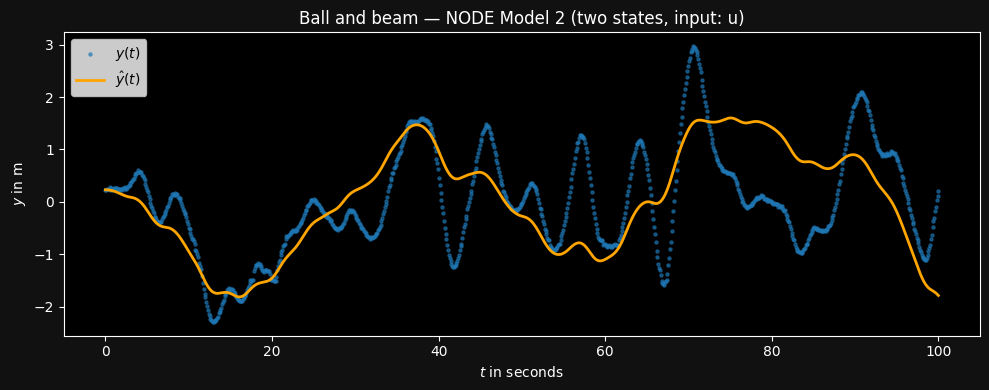

In [20]:
with torch.no_grad():
    pred2 = predict_NODE2(node_func2).numpy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(tsteps, y, label=r"$y(t)$", s=5, alpha=0.6)
ax.plot(tsteps, pred2, label=r"$\hat{y}(t)$", linewidth=2, color="orange")
ax.set_title("Ball and beam — NODE Model 2 (two states, input: u)")
ax.set_xlabel(r"$t$ in seconds")
ax.set_ylabel(r"$y$ in m")
ax.legend(loc="upper left")
ax.set_facecolor("#000000")
fig.patch.set_facecolor("#111111")
ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white"); ax.title.set_color("white")
for spine in ax.spines.values(): spine.set_edgecolor("white")
plt.tight_layout()
plt.show()



Unfortunately, the extended NODE model did not perform significantly better. A deeper look into the literature reveals that the Newtonian approach is too simple: $\ddot{r}(t)$ actually depends on $\alpha(t)$, $\dot{\alpha}(t)$, and $\dot{r}(t)$:
$$\ddot{r}(t) = f(\alpha(t), \dot{\alpha}(t), \dot{r}(t)).$$

Using a Lagrangian approach, we find the ball's acceleration also depends on the change of beam angle $\dot{\alpha}(t)$ and the ball's speed $\dot{r}(t)$ (due to friction). We therefore extend the NODE topology to:
$$\frac{\mathrm{d}}{\mathrm{d} t}\begin{bmatrix}\hat{r}(t)\\\\\hat{\dot{r}}(t)\end{bmatrix} = \begin{bmatrix}\hat{\dot{r}}(t) \\\\ \hat{f}_w(\alpha(t), \dot{\alpha}(t), \hat{\dot{r}}(t))\end{bmatrix}.$$

We require the derivative of the beam angle, which is not directly in the data. Since we have a continuous interpolation, we can differentiate it analytically using `CubicSpline.derivative()`.


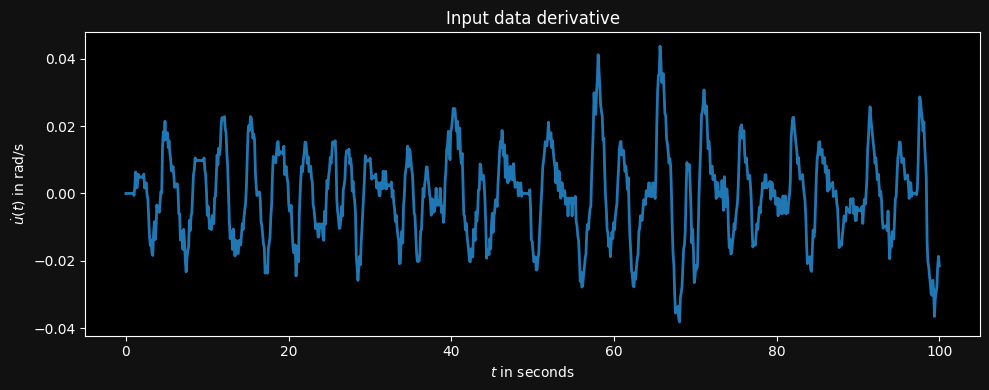

In [21]:
u, y, dt, tspan, tsteps = loaddata(normalize=False)
interp_input_cs = CubicSpline(tsteps, u)         # quadratic/cubic spline for differentiability
interp_deriv = interp_input_cs.derivative()       # analytic derivative

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tsteps, interp_deriv(tsteps), linewidth=2)
ax.set_title("Input data derivative")
ax.set_xlabel(r"$t$ in seconds")
ax.set_ylabel(r"$\dot{u}(t)$ in rad/s")
ax.set_facecolor("#000000")
fig.patch.set_facecolor("#111111")
ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white"); ax.title.set_color("white")
for spine in ax.spines.values(): spine.set_edgecolor("white")
plt.tight_layout()
plt.show()


With the additional input features we extend the second-order NODE model:

In [22]:
torch.manual_seed(294)

# Use non-normalized data for this model (as in the original)
u, y, dt, tspan, tsteps = loaddata(normalize=False)
interp_input_cs = CubicSpline(tsteps, u)
interp_deriv = interp_input_cs.derivative()

y_tensor = torch.tensor(y, dtype=torch.float32)
tsteps_tensor = torch.tensor(tsteps, dtype=torch.float32)

# NODE Model 3: ANN inputs = [r, r_dot, u(t), u_dot(t)], output = r_ddot
class NODEFunc3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )

    def forward(self, t, x):
        # x: (batch, 2)  [r, r_dot]
        t_val = t.item()
        u_t = torch.tensor([[float(interp_input(t.item()))]], dtype=torch.float32)
        du_t = torch.tensor([[float(interp_deriv(t.item()))]], dtype=torch.float32)
        inp   = torch.cat([x, u_t, du_t], dim=-1)   # 4 features
        r_dot = x[:, 1:2]
        r_ddot = self.net(inp)
        return torch.cat([r_dot, r_ddot], dim=-1)

node_func3 = NODEFunc3()
u0_3 = torch.tensor([[y[0], 0.0]], dtype=torch.float32)

def predict_NODE3(model):
    pred = odeint(model, u0_3, tsteps_tensor, method='rk4', options={'step_size': float(dt)})
    return pred[:, 0, 0]

def loss_NODE3(model):
    pred = predict_NODE3(model)
    return torch.sum((y_tensor - pred) ** 2)

optimizer3 = torch.optim.LBFGS(node_func3.parameters(), lr=0.01, max_iter=60, history_size=10,
                                line_search_fn='strong_wolfe')
losses3 = []

def closure3():
    optimizer3.zero_grad()
    loss = loss_NODE3(node_func3)
    loss.backward()
    losses3.append(loss.item())
    return loss

print("Training NODE Model 3 (two states, ANN inputs: r, r_dot, u, u_dot)...")
optimizer3.step(closure3)
print(f"Final loss: {losses3[-1]:.4f}")


Training NODE Model 3 (two states, ANN inputs: r, r_dot, u, u_dot)...
Final loss: 463.1205


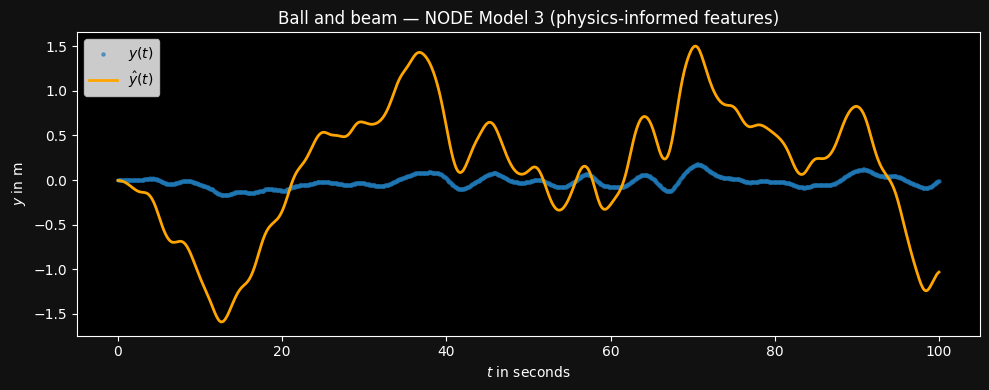

In [24]:
with torch.no_grad():
    pred3 = predict_NODE3(node_func3).numpy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(tsteps, y, label=r"$y(t)$", s=5, alpha=0.6)
ax.plot(tsteps, pred3, label=r"$\hat{y}(t)$", linewidth=2, color="orange")
ax.set_title("Ball and beam — NODE Model 3 (physics-informed features)")
ax.set_xlabel(r"$t$ in seconds")
ax.set_ylabel(r"$y$ in m")
ax.legend(loc="upper left")
ax.set_facecolor("#000000")
fig.patch.set_facecolor("#111111")
ax.tick_params(colors="white"); ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white"); ax.title.set_color("white")
for spine in ax.spines.values(): spine.set_edgecolor("white")
plt.tight_layout()
plt.show()


Although the model fit is certainly not perfect, the physics-driven feature engineering helped to craft a solid starting base to further fine-tune the model, e.g., by:
- playing around with further feature engineering,
- tuning the ODE and optimization solvers' configuration, or
- via a hyperparameter optimization of the NODE's RHS ANN.
